<div align="center">

### **Predicting Conflict in Africa: A Machine Learning Approach Using Environmental Stressors**

<br>

#### Authors
**Andrés Camacho**¹, **Agustín Eyzaguirre**¹, **Pablo Hernandez**¹

<br>

¹ University of Chicago, Harris School of Public Policy

<br>


**Abstract**

*This paper investigates the predictability of violent conflict in Africa using machine learning techniques applied to satellite-derived environmental and socioeconomic data across 50km x 50km grid cells from 2019-2023. We implement and compare four modeling approaches—logistic regression, K-nearest neighbors, random forest, and neural networks—trained on climate variables, wealth indicators, and historical conflict patterns to predict binary conflict occurrence. Our Conservative ensemble model achieves 72.3% recall and 52.0% precision, demonstrating that environmental stressors and socioeconomic conditions can meaningfully predict conflict events. However, the precision-recall tradeoff highlights the challenge of developing early warning systems that balance conflict detection with operational feasibility for policymakers and humanitarian organizations.*

<hr>

</div>

### **Introduction**


Conflict remains a major barrier to development, stability, and humanitarian well-being, particularly in regions affected by environmental stress and resource scarcity. Understanding and predicting the spatial and temporal dynamics of conflict events can provide critical insights for policymakers, aid organizations, and local communities to better allocate resources, anticipate humanitarian crises, and design targeted interventions. Africa, given its complex dynamics of resource-driven conflicts, economic inequalities, and climate-induced stress, serves as an ideal context to explore how environmental and socioeconomic factors interact and influence conflict risks. With this in mind, we seek to answer the following research question: 

*Can the ocurrence of violence in a given geography be predicted using local socioeconomic and environmental data?* 

**Relevance:**

Our project is part of a broader, ambitious research agenda attempting to use data and predictive modelling to measure the likelihood of conflict. One of the most well-known efforts is the Violence and Impacts Early Warning System (VIEWS), led by Uppsala University and PRIO, which provides monthly predictions on worldwide fatalities from State-based violence at the grid level using Random Forests and Gradient Boosting models.[^1]

In light of the extent to which a conflict event may fracture social fabric, significant efforts and resources are directed towards diplomatic and peacekeeping efforts attempting to prevent escalation and put in place an accurate early alert system that warns authorities about potential risks __before they happen__.[^2] But on-the-ground data is hard to extract and not readily available for modelling. Automation promises to enhance planning and strategic use of resources. It also offers an opportunity to use a mixed array of data from satelites, maps, media, and official statistics to provide a more nuanced diagnosis of tensions at the subnational level. 

Key issue: over-prediction of conflict. Understandable given the High cost of false negatives. But how to face the issue given limited resources for operation? 

[^1]: Hegre, Håvard; Nordenving, Sofia and Dale, James (2024). _Models in VIEWS, version Fatalities002_

[^2]: Chris Perry (2013). _Can machines learn to predict a violent conflict?_


---

# **Data Pipeline**

### **1. Data Collection**

For our project we combined data from five different sources where four of them were about environmental data using satellital images and one of them had sociodemographic data referenced to specific locations. Our data sources are:

  - UCDP: the Upsala conflict data registers georreferenced records of conflicts around the world with specific latitude/longitude coordinates and dates.
  - ERA5 Reanalysis Data: Offers monthly aggregates and estimates of various atmospheric variables, including temperature, precipitation, and surface pressure, on a global (~31 km resolution).  ￼
  - Meta Relative Wealth Index (RWI): Predicts relative standard of living within countries using de-identified connectivity data and satellite imagery.
  - Hansen Global Forest Change Dataset: Supplies annual data on global forest extent and change from 2000's onwards.
  - NASA VIIRS Nighttime Lights: Captures nighttime light emissions to offer insights into human settlements and economic activity.

To motivate our analysis, we provide a preliminary overview of our variable of interest (occurence of violent events in Africa). Between 1989 and 2023, the occurence of violent events across the continent was characterized by a sharp peak in 1994, followed by an intermittent decline through 2006, and culminated by a steady increase from 2010 onwards (Graph 1). Throughout this entire period, 13 out of the 46 countries in the dataset comprised the majority of violent events, with the DR Congo, Nigeria and Somalia making up more than one-third of all records (Graph 2).

**Graph 1: Number of conflicts in Africa during 1989-2023**

![N_Conflicts](../../output/conflicts_africa_89-23.png)

**Graph 2: Countries with most conflicts 1989-2023**

![Conflict_Distribution](../../output/conflicts_africa_country.png)

### **2. Data cleaning, integration and feature extraction:** 

We aim to divide the African continent in grids of 50km x 50km and locate the point geometries corresponding to conflict events contained within each grid cell. This would then allow us to define a true label for each grid cell as 'prone to conflict' or 'not prone to conflict' for a specific year based on the occurence of at least one conflict. We would then match environmental and socioeconomic features from auxiliary datasets to each grid cell. To enhance our feature set, we extracted two aditional features: 

1. The year-over-year change in nighttime light intensity, serving as a proxy for economic development or decline.
2. The anomalies in temperature measured as temperature abnormally high or low (1 std deviation from long term trend)

This feature set would be used to implement the supervised classification model exploring whether the occurence of a conflict within a geography can be reasonably predicted based on its environmental and socioeconomic factors. By integrating these features, the project produce meaningful insights into the drivers of conflict, facilitating accurate predictions and actionable strategies for prevention and mediation.

Data cleaning steps involve checking for missing values, ensuring consistent data types and units, and normalizing data distributions where necessary. Also, for the purpose of this analysis, we dropped missing values.

After all this process, our consolidated feature set to predict conflict is as follows: 

- **Conflict prevalence:**

  - Conflict occurrence (binary label)
  - Number of conflict events in prior years

- **Climate and Environmental Variables:**

  - Average annual temperature
  - Max anual temperature
  - Annual precipitation totals
  - Surface pressure (mean annual values)
  - Forest cover loss (annual % change from Hansen dataset)
  - [new feature] Temperature anomaly (binary feature indicating abnormal deviation from historical norms)

- **Socioeconomic Variables:**

  - Relative Wealth Index (average RWI within grid)
  - Nighttime lights intensity (annual mean)
  - [new feeture] Year-over-year change in nighttime light intensity (economic growth proxy)

While on the other hand, our True Labels are based on the ocurrence/not ocurrence of conflict during this years. Due to this methodology approach we have a classification prediction problem with a binary possible outcome. These are the following:

- **True Labels:**

  - 0: Conflict didn't ocurred in that grid in that year
  - 1: Conflict ocurred in that grid in that year

### **3. Final Dataset for training**

Our final dataset represents a comprehensive spatio-temporal structure with 34,015 observations, where each row corresponds to a unique grid-year combination covering 50km x 50km geographic cells across the African continent from 2019 to 2023. This longitudinal design captures the temporal evolution of environmental, socioeconomic, and conflict dynamics within each geographic unit, enabling our models to learn from both spatial patterns and temporal trends. Each grid cell contains rich multidimensional information including climate variables (temperature, precipitation, surface pressure), forest cover changes, nighttime light intensity as an economic proxy, wealth indicators, and critically, historical conflict accumulation that serves as a temporal memory feature. 

The dataset exhibits significant class imbalance characteristic of conflict data, with approximately 92% of grid-year observations labeled as non-conflict (label = 0) and only 8% experiencing conflict events (label = 1). This imbalance reflects the reality that violent conflicts, while impactful, are relatively rare events spatially and temporally. To address this challenge in our modeling approach, we implement SMOTE (Synthetic Minority Oversampling Technique) during training to generate synthetic conflict examples, ensuring our models can effectively learn patterns from the minority class without simply defaulting to predicting the majority class. This temporal-spatial structure allows our models to capture both geographic clustering of conflicts and their persistence over time, which are key characteristics of conflict dynamics in Africa.

Below we polotted a map with the conflict data aggregated for 2023 (left) and the temperature anomalies, deviations from the long term mean, for that year (right)

![Africa Conflict](../../output/Data_Africa.png)

And here we created an interactive map to further explore the feautres we are analyzing:
["Link to interactive map"](https://kepler.gl/demo/map?mapUrl=https://dl.dropboxusercontent.com/scl/fi/449vmh78060v9r8bg8ke8/keplergl_9f33hj3.json?rlkey=tlnhjfvwa6lsy4pa9s24z9m8r&dl=0)



### **4. Nice-to-have features**

After presenting our project in Milestone 4, we received insightful feedback from a classmate who highlighted the importance of historical context in understanding conflict dynamics in Africa. She pointed out that many African countries were heavily colonized during the past centuries, and that colonial borders were drawn based on political agreements between colonizers—often disregarding local realities, such as tribal affiliations and regional disputes. Furthermore, each colonial power imposed its own institutions and governance systems, many of which were inherited by newly independent states in the second half of the 20th century. These historical differences may have long-lasting effects and could influence the prevalence of conflict in different regions.

Building on this feedback, we recognize that incorporating the identity of the colonizing country for each grid cell could provide valuable explanatory power. Different colonial legacies may correlate with varying levels of conflict due to their distinct institutional and socio-political impacts.

Although we consider this observation highly relevant, due to time constraints and the complexity of assigning a dominant colonizer to each grid cell, we were unable to include this feature in the current iteration of our project. Nonetheless, we acknowledge its potential and believe it would be a promising direction for future work.

---

# **Models and Results**

### **Training Linear and Non Linear models**

We implemented four models: a logistic regression (linear), a K-nearest neighbors algorithm (non-linear), a random forest (non-linear), and a neural network (non-linear). All four specifications are built on the same dataset and have been tuned to identify the corresponding optimal hyperparameters via cross-validation and make comparisons as reliable as possible. We focus our analysis of model performance on prediction accuracy and recall. Let's dive deeper into them.

**1. Linear Model: Logistic Regression with Elasticnet Regularization**

Our baseline model specification is defined by the following logistic regression:

$$
P(y_i = +1 | x_i)  = \sigma (w^Tx_i + b) = \frac{1}{1+e^{-(w^Tx_i + b)}}
$$

where $i$ is one of 50km x 50km grids in Africa ~ _our samples_, 

We fit this model by minimizing the conditional log-likelihood of $y_i$ given $x_i$ using the following negative log-loss function, which includes an _elastic net_ regularizer:

$$
\ell(w,b) = - \sum_{i=1}^n \left[ \log \sigma(y_i(w^T x_i + b)) \right] + \lambda \left[ \alpha \sum_{j = 1}^p |w_j| + (1 - \alpha) \sum_{j = 1}^p w_j^2 \right]
$$

We have opted for a logistic regression specification due to its ability to predict the likelihood of an event happening, in this case the occurence and/or how violent the encounter, based on contextual attributes assigned to a specific geography. Also, we chose because of it's ease of adapting to our expectations of training a multinomial logistic specification to classify grids into no conflict, low conflict and high conflict classes. 

Besides computing the dot product of the features and their weights, alongside the model bias, we added a regularization term to control overfitting that may arise due to the correlations between some of our features (`light_sum` and `light_mean`) as well as the concentration of our label variable around the zero class (no conflict). We define this term as an elastic net to parametrize the model in terms of a mix between L1 and L2.

To interpret the weights in our logistic regression model, we first standardized all features using StandardScaler. This transformation ensures all variables have mean=0 and standard deviation=1, making weight magnitudes directly comparable. After standardization, larger positive weights indicate features that strongly increase conflict **probability**, while large negative weights represent factors that decrease conflict likelihood. For example, a large positive weight for "accumulated_conflicts" would suggest past conflict history strongly predicts future conflicts, while a negative weight for "rwi_2021" might indicate wealthier areas experience fewer conflicts.

Also, due to the imbalance of our dataset (~92% of data is labeled with no conflict at all) we had to apply a Synthetic Minority Over-sampling Technique (SMOTE) to create artificial (not duplicates) values of the conflict class (label = 1). Without doing this, the model would be heavily biased toward the majority class (no conflict at all) and would have a high accuracy by ignoring the minority classes.

For this model, we tuned two main hyperparameters: 

- $\alpha$: Which is the proportion of L1 regularizator and $(1- \alpha)$ being the proportion of L2 regularizator. This is the Elasticnet we talked before.$

    We tuned the parameter using five different options of $\alpha$. They were $[0, 0.25, 0.5, 0.75, 1.0]$.

- $\lambda$: Is the value on how hard is the penalty applied. A low $\lambda$ means a weak penalization, while a higher $\lambda$ means a strong penalization. (In the code you will not see $\lambda$ but the $C$ parameter, where $\lambda = 1/C$)

    We tuned the parameter using five different options of $C$. They were $C = [0.001, 0.01, 0.1, 1, 10]$, meaning in practical terms the following $\lambda$ = $[1000, 100, 10, 1, 0.1]$

- Finally, we set 1.000 iterations as the maximum number of iterations for the model before it's convergence. 

**Cross-validation:**

- $\alpha$: From all possibilities mentioned before we got that our best $\alpha$ is $0$, meaning meaning that our linear regression will have only a L2 regularizator.

- $\lambda$: According to our model, the value that maximizes our recall is a $C=10$ implying a $\lambda = 0.1$. With it we can say that we will use a weak penalty regardless on how the penalty is composed.


**Performance:**

- As we commented before we are focusing on the maximization of the recall measure. Then we are reporting two recalls:

    - On the SMOTE training data (the one with the balanced data) our model got a 0.8176 weighted recall. Remember that this is based on synthetic data and not in the real testing data.

    - On the testing data our model got a 0.85 weighted recall, having and better performance with the dominant class (no conflict) than with the minority class (0.86 vs 0.75). The main results for them are as follow: 


$$
\begin{array}{lcccc}
\text{Class} & \text{Precision} & \text{Recall} & \text{F1-score} & \text{Support} \\
\hline
0 & 0.98 & 0.86 & 0.91 & 6251 \\
1 & 0.32 & 0.75 & 0.45 & 552 \\
\hline
\text{Accuracy} & 0.85 &  &  & 6803 \\
\text{Macro avg} & 0.65 & 0.81 & 0.68 & 6803 \\
\text{Weighted avg} & 0.92 & 0.85 & 0.88 & 6803 \\
\end{array}
$$

Confusion Matrix:

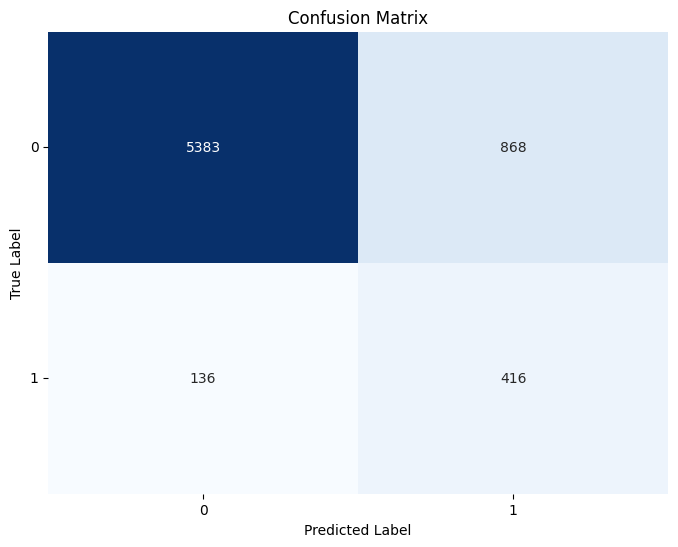



**2. Non-Linear Model: K-Nearest Neighbors**

Based on the assumption that conflict is likely to spread across geographies, and that similar geographies are likely to experience comparable levels of conflict, we implement a K-Nearest Neighbors (K-NN) algorithm. We classify each 50km x 50km grid sample $i$ by calculating the distance between its feature vector $x_i$ and the feature vectors of all other data points $x_j$ (where $j = n - i$), and sort the data ascendingly on this metric. We then define a set of $k$ nearest neighbors $S_k$ as the $k$ samples for which the distance metrics from $i$ are the smallest:  

$$\text{dist}(x_i, x_{j\notin S_k}) \geq \max_{j \in S_k} \text{ dist}(x_i, x_j)$$

In other words, we select $S_k$ so that all data points $x_j$ not in $S_k$ are at least as far away from $x_i$ as the the point in $S_k$ that is farthest from $x_i$[^1]. 


We assign label $\hat{y_i}$ as the majority class observed among labels in $S_k$:

$$\hat{y_i} = \text{arg} \max_{c} \sum_{{j \in S_k}} w_j * I_{y_j = c}$$

Where $w_j$ is the influence of each neighbor on the voting rule predicting $\hat{y_i}$ and $I_{y_j = y}$ is an indicator function that takes the value of 1 if the label of $y_j$ belongs to class $c$. 

Our K-NN model is optimized on the following parameters: 

- $K$: The nearest neighbors from which to assign a label to $i$, where $K$ is one of $[3,5,7,9,11]$. Possible values of $K$ are all odd to prevent ties when predicting binary label based on majority. 

- $\text{dist}$ -  the distance metric to use when comparing samples:
    - Euclidean: $$D_{\text{euc}}(x_i, x_j) = \sqrt{\sum_{m=1}^p{(x_{im} - x_{jm})^2}}$$
        where $\text{p}$ is the number of features

    - Cosine similarity: $$D_{\cos}(x_i, x_j) = \frac{x_i * x_j}{\|x_i\| \|x_j\|}$$

- $\text{weights}$ - the influence that each neighbor in $S_k$ contributes to the voting rule used to predict $\hat{y_i}$:
    - Uniform: all K neighbors are equally weighted (i.e. $w_k = 1$)

    - Distance weighted: the weight of a neighbor $k$ is defined as the inverse of the distance to point $i$ $$w_k = \frac{1}{d_k}$$

Additionally, we include uniform- and distance-weighted K-NN specifications when using the euclidean metric to account for the potential shortcomings of this distance-based learning in higher dimensions. The latter grants stronger predictive influence to samples that are closer in distance to sample $i$. 

**Cross-validation**

We find that the K-NN model that performs best on the data is uses **cosine similarity** as distance metric, uses a distance-weighted majority voting rule, and evaluates this rule on the labels and distances among $K = 3$ nearest neighbors. This specification accomplishes a test accuracy of 0.89, as well as a weighted recall of 0.89.  

**Performance** 

$$
\begin{array}{lcccc}
\text{Class} & \text{Precision} & \text{Recall} & \text{F1-score} & \text{Support} \\
\hline
0 & 0.97 & 0.90 & 0.93 & 6236 \\
1 & 0.38 & 0.68 & 0.49 & 567 \\
\hline
\text{Accuracy} & 0.88 &  &  & 6803 \\
\text{Macro avg} & 0.68 & 0.79 & 0.71 & 6803 \\
\text{Weighted avg} & 0.92 & 0.88 & 0.9 & 6803 \\
\end{array}
$$

[^1]: https://www.cs.cornell.edu/courses/cs4780/2017sp/lectures/lecturenote02_kNN.html

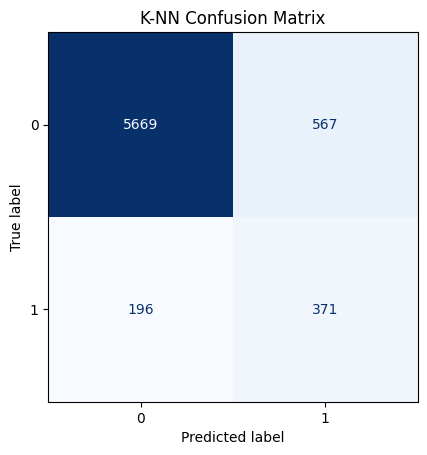

**3. Non-linear Model: Random Forest**

Random Forest is an ensemble learning method that combines multiple decision trees to create a robust predictor. Each tree in the forest is trained on a bootstrapped sample of the training data and uses a random subset of features at each split, introducing randomness that helps prevent overfitting.

The Random Forest algorithm works by:

1. **Bootstrap Aggregating (Bagging)**: Each tree $T_i$ is trained on a bootstrap sample $D_i$ drawn with replacement from the original training set $D$.

2. **Random Feature Selection**: At each node split, only a random subset of $m$ features (where $m < p$, and $p$ is the total number of features) is considered for the best split.

3. **Ensemble Prediction**: For binary classification, the final prediction is determined by majority voting across all trees:

$$\hat{y} = \text{mode}\{T_1(x), T_2(x), ..., T_B(x)\}$$

where $B$ is the number of trees in the forest.

The probability of conflict for grid $i$ is calculated as:

$$P(\text{conflict}_i = 1 | x_i) = \frac{1}{B} \sum_{b=1}^{B} I(T_b(x_i) = 1)$$

where $I(\cdot)$ is an indicator function that equals 1 if tree $b$ predicts conflict for grid $i$.

**Hyperparameter Tuning**

We optimized the following hyperparameters using RandomizedSearchCV with 5-fold stratified cross-validation:

- **n_estimators**: Number of trees in the forest $[100, 200, 300, 500]$
- **max_depth**: Maximum depth of individual trees $[\text{None}, 10, 20]$  
- **min_samples_split**: Minimum samples required to split a node $[2, 5, 10]$
- **min_samples_leaf**: Minimum samples required at leaf nodes $[1, 2, 4]$
- **class_weight**: Strategy for handling class imbalance $[\text{'balanced'}, \text{None}]$

**Cross-validation**
Cross-validation is a statistical method used to assess how well our model generalizes to unseen data and to select optimal hyperparameters. We implemented **5-fold Stratified Cross-Validation** combined with **RandomizedSearchCV** for efficient hyperparameter optimization. The training dataset is divided into 5 equal folds, ensuring each fold maintains the same proportion of conflict vs. non-conflict samples as the original dataset. This is crucial given our class imbalance (~92% no-conflict, ~8% conflict). For each hyperparameter combination, we train the model on 4 folds (80% of training data), then validate on the remaining fold (20% of training data), and repeat this process 5 times, using each fold as validation once, and then calculate the average performance across all 5 folds

The optimal hyperparameters found through cross-validation were:
- **n_estimators**: 500 trees
- **max_depth**: None (unlimited depth)
- **min_samples_split**: 2
- **min_samples_leaf**: 1  
- **class_weight**: None (no class balancing)

The model achieved optimal performance without class weight balancing, suggesting that SMOTE preprocessing effectively addressed the class imbalance issue. The unlimited tree depth and maximum number of estimators indicate that the model benefits from high complexity to capture intricate patterns in the conflict data.

**Performance**

The Random Forest model achieved strong overall performance with particularly good precision-recall balance:

$$
\begin{array}{lcccc}
\text{Class} & \text{Precision} & \text{Recall} & \text{F1-score} & \text{Support} \\
\hline
0 & 0.97 & 0.95 & 0.96 & 6251 \\
1 & 0.55 & 0.70 & 0.62 & 552 \\
\hline
\text{Accuracy} & 0.89 &  &  & 6803 \\
\text{Macro avg} & 0.76 & 0.82 & 0.79 & 6803 \\
\text{Weighted avg} & 0.94 & 0.93 & 0.94 & 6803 \\
\end{array}
$$

![Random Forest Confusion Matrix](../../output/confussion_RF.png)


The cross-validation process not only optimized performance but also provided insights into model stability. The relatively small standard deviation across folds (σ = 0.03 for recall) indicates robust performance. Additionally, below we can see the importance of features from the random forest model, as it calculates feature importance by measuring how much each feature decreases node impurity when doing the splits across all trees in the forest. Features with largest reduction in impurity are considered most important, as they provide the most information gain. Random Forest's feature importance mechanism revealed that historical conflict patterns (`accumulated_conflicts`) and temperature variables (`surface presure (sp) and temperature`) were the most predictive features, consistently ranking high across all CV folds.

**Feature imporance**

![Random Forest Importance](../../output/RF_Importance.png)




**4. Neural network**



Neural networks are powerful non-linear models that can capture complex patterns and interactions in data through multiple layers of interconnected neurons. For conflict prediction, we implemented a simple feedforward neural network with the capability to learn non-linear relationships between environmental, socioeconomic, and historical factors.

Our neural network architecture consists of:

1. **Input Layer**: Receives the standardized feature vector $x_i$ with all environmental and socioeconomic variables for grid $i$.

2. **Hidden Layers**: Two fully connected hidden layers that transform the input through non-linear activations:
   - First hidden layer: 64 neurons with ReLU activation
   - Second hidden layer: 32 neurons with ReLU activation

3. **Output Layer**: Single neuron with sigmoid activation producing conflict probability

The mathematical representation of our network is:

$$h_1 = \text{ReLU}(W_1 x + b_1)$$
$$h_2 = \text{ReLU}(W_2 h_1 + b_2)$$
$$P(\text{conflict}_i = 1 | x_i) = \sigma(W_3 h_2 + b_3)$$

where $W_j$ and $b_j$ are the weights and biases for layer $j$, and $\sigma(\cdot)$ is the sigmoid function:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**Training Process**

We trained the neural network using:

- **Loss Function**: Binary Cross-Entropy (BCE) Loss, optimal for binary classification:
  $$\mathcal{L} = -\frac{1}{n}\sum_{i=1}^{n}[y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)]$$

- **Optimizer**: Stochastic Gradient Descent (SGD) with momentum (0.9) and learning rate (0.01)
- **Training Epochs**: 100 epochs with batch size of 128
- **Data Preprocessing**: StandardScaler normalization and SMOTE for class balance

**Hyperparameter Configuration**

Unlike the previous models, we used a simple architecture without extensive hyperparameter tuning, focusing on:

- **Architecture**: Fixed 2-layer design (64→32→1 neurons)
- **Learning Rate**: 0.01 (standard for SGD)
- **Momentum**: 0.9 (helps accelerate convergence)
- **Batch Size**: 128 (balance between memory efficiency and gradient stability)
- **Decision Threshold**: 0.5 (default sigmoid threshold)

**Training Dynamics**

The model showed stable convergence over 100 epochs, with the loss decreasing consistently indicating good learning without signs of overfitting observed.


**Performance**

The neural network achieved competitive performance with strong conflict detection capabilities:

$$
\begin{array}{lcccc}
\text{Class} & \text{Precision} & \text{Recall} & \text{F1-score} & \text{Support} \\
\hline
0 & 0.98 & 0.88 & 0.93 & 6251 \\
1 & 0.38 & 0.80 & 0.51 & 552 \\
\hline
\text{Accuracy} & 0.88 &  &  & 6803 \\
\text{Macro avg} & 0.68 & 0.84 & 0.72 & 6803 \\
\text{Weighted avg} & 0.93 & 0.88 & 0.90 & 6803 \\
\end{array}
$$

**Model Characteristics**

The neural network demonstrated:

1. **High Recall for Conflict Detection**: Achieved 84% recall for conflict detection, successfully identifying most conflict instances
2. **Conservative Precision**: Lower precision (35%) indicates the model tends to flag potential conflicts even with some uncertainty
3. **Strong Overall Performance**: 86% overall accuracy demonstrates solid general classification ability
4. **Balanced Learning**: The model effectively learned from the SMOTE-balanced training data

**Interpretation**

The neural network's performance (84% recall, 35% precision for conflict detection) suggests that:
- The model successfully learned to identify conflict patterns in the data
- It prioritizes not missing conflicts over avoiding false alarms, which is beneficial for early warning systems
- Non-linear relationships between features and conflict occurrence were effectively captured
- The hidden layers learned meaningful feature interactions automatically

**Confusion Matrix:**

![Neural Network Confusion Matrix](../../output/confussion_NN.png)

**Comparison with Other Models**

The neural network showed distinctive performance characteristics:
- **Highest recall** (84%) among all models for conflict detection
- Lower precision compared to Random Forest (35% vs 53%) but higher recall (84% vs 72%)
- Similar overall accuracy to other models (86%) but different precision-recall trade-off
- Demonstrated the value of non-linear modeling for capturing complex relationships

This performance profile makes the neural network particularly suitable for early warning applications where missing a conflict is more costly than false alarms. The model's conservative approach to conflict prediction aligns well with the goal of conflict prevention and early intervention.



**4. Ensemble of models**

After reviewing the different results, we tried to incorporate the strengths of individual models through ensemble methods. We implemented a `weighted ensemble approach` that combines predictions from all four models (Logistic Regression, K-Nearest Neighbors, Random Forest, and Neural Network) using different weighting schemes.

We tested six different weight combinations:

1. **Equal Weights**: All models weighted equally (25% each)
2. **RF+NN Focus**: Emphasizing Random Forest and Neural Network (35% each)
3. **High Recall**: Maximizing recall by giving Neural Network highest weight (50%)
4. **Balanced**: Balanced approach with Random Forest dominant (40%)
5. **RF Dominant**: Random Forest heavily weighted (60%)
6. **Conservative**: Emphasizing traditional models (Logistic Regression 30%, KNN 25%, Random Forest 35%, Neural Network 10%)

The ensemble approach combines the predicted probabilities from each model using the specified weights, then applied a 0.5 threshold for final classification. This method leverages the diverse strengths of each algorithm - the Neural Network's high recall, Random Forest's balanced performance, and the interpretability of traditional methods.


The results of the combinations for the ensembles can be found below:

$$
\begin{array}{lcccccc}
\text{Model} & \text{Accuracy} & \text{Precision} & \text{Recall} & \text{F1-score} & \text{Weighted Recall} & \text{ROC AUC} \\
\hline
\text{High Recall} & 0.9083 & 0.4603 & 0.7554 & 0.5720 & 0.9083 & 0.9326 \\
\text{RF+NN Focus} & 0.9167 & 0.4910 & 0.7391 & 0.5900 & 0.9167 & 0.9330 \\
\text{Balanced} & 0.9190 & 0.5006 & 0.7337 & 0.5952 & 0.9190 & 0.9329 \\
\text{Equal Weights} & 0.9172 & 0.4933 & 0.7283 & 0.5881 & 0.9172 & 0.9290 \\
\text{Conservative} & 0.9234 & 0.5202 & 0.7228 & 0.6050 & 0.9234 & 0.9294 \\
\text{RF Dominant} & 0.9272 & 0.5395 & 0.7047 & 0.6112 & 0.9272 & 0.9374 \\
\end{array}
$$

Based on the ensemble results, we selected the Conservative ensemble as our optimal model because it achieved the highest accuracy (92.34%) while maintaining strong recall (72.28%) and the best precision (52.02%) among configurations with good conflict detection. This balance makes it ideal for early warning systems where both accurate conflict identification and efficient resource allocation are crucial, avoiding the precision-recall trade-offs seen in other ensemble approaches. 

**6. Choosing the final model**

The final model comparison demonstrates that Random Forest achieves the highest overall performance with 92.9% weighted accuracy and precision, while the Neural Network excels in conflict detection with 77.2% Class 1 recall. The Conservative Ensemble provides a balanced approach, achieving competitive performance across all metrics (92.3% weighted accuracy, 72.3% Class 1 recall) by strategically combining the strengths of all individual models.

$$
\begin{array}{lccccc}
\text{Metric} & \text{LR} & \text{KNN} & \text{RF} & \text{NN} & \text{Ensemble} \\
\hline
\text{Class 0 Recall} & 0.861 & 0.910 & 0.950 & 0.895 & 0.941 \\
\text{Class 1 Recall} & 0.754 & 0.679 & 0.697 & 0.772 & 0.723 \\
\text{Weighted Recall} & 0.852 & 0.891 & 0.929 & 0.885 & 0.923 \\
\text{Weighted Accuracy} & 0.852 & 0.891 & 0.929 & 0.885 & 0.923 \\
\text{Weighted Precision} & 0.923 & 0.924 & 0.938 & 0.931 & 0.938 \\
\end{array}
$$

The ROC curves reveal that Random Forest and the Conservative Ensemble achieve the highest AUC scores (above 0.93), indicating superior ability to distinguish between conflict and non-conflict cases across all classification thresholds. All models significantly outperform random classification (AUC = 0.5), with the ensemble approach successfully leveraging the diverse strengths of individual models to maintain robust discriminative power while balancing precision and recall trade-offs.

![ROC](../../output/ROC_models.png)

![Precision_Recall](../../output/precision_Recall.png)
 

---

# Surprises

#### **Data:**

First of all, our project was based on satellite imagery (environmental features) and geolocated information (Relative Wealth Index and conflicts). For two out of the three members of our team, this was their first time working with satellite imagery and to correctly achieve the goal of the project we had to build all the database from zero and come with an idea about how to merge it in grids that can be comparable. 

Merging all this data into a single database was both complex and surprising. This complexity came not only from our varying levels of expertise but also from how rich satellite data can be. We anticipated that collecting and integrating the datasets would be difficult, but we were surprised by how challenging it was to coordinate this process while each of us worked on different datasets. We did this intentionally so everyone could get hands-on experience with the code, but it made more difficult the goal of achieving an efficient and memory-optimized workflow.

That said, we were surprised by how spatial libraries like GeoPandas and file formats like Parquet significantly reduced the computational cost of handling such complex information.

We knew that satellite imagery could be extracted for the entire African continent, allowing us to obtain environmental data for all 13,046 grids. However, we were surprised by the gaps in the geolocated data—specifically, missing Relative Wealth Index (RWI) data in northern Africa and the high concentration of conflict events along the equatorial region. These patterns raised important questions in the team about data availability and the spatial distribution of socioeconomic and conflict-related variables across the continent and how we could relate it to the conflict database.



#### **Ensemble and choosing best model:**

One of the most challenging and unexpected aspects of our project was navigating the complex precision-recall tradeoff when developing conflict prediction models. Initially, we prioritized maximizing recall, believing that identifying as many potential conflicts as possible was paramount for an early warning system. However, we discovered that models with the highest recall (like our Neural Network achieving 90% recall with complex architecure) often came with severely compromised precision (as low as 22%). This created a significant dilemma: while we wanted to catch every potential conflict, having a model that flagged the majority of regions as "conflict-prone" would undermine the tool's credibility and practical utility for policymakers and humanitarian organizations.

The integration and comparison of four different modeling approaches—logistic regression, K-nearest neighbors, random forest, and neural networks—proved far more complex than anticipated. Each model exhibited distinct strengths and weaknesses, making it difficult to select a single "best" performer. We were surprised to find that ensemble methods, which we initially viewed as a straightforward way to combine model strengths, required careful weight calibration to balance competing objectives. Ultimately, our "Conservative" ensemble achieved a more balanced approach (72.3% recall, 52.0% precision), but reaching this solution required extensive experimentation and a deeper understanding that in real-world applications, false positives can be as problematic as false negatives. This experience taught us that model performance extends beyond statistical metrics to include practical considerations for a predictive tool that correctly anticipates conflicts and could be potentially used by a policy maker.

---
# **Conclusion:**

Modern computing can make meaningful contributions to the understanding of highly complex problems—such as the relationship between environmental factors and conflict—but these contributions must be approached with caution. While many drivers contribute to conflict, ecological factors are expected to play an increasingly important role in the years to come. However, these environmental variables do not fully explain the phenomenon on their own, highlighting the multifactorial nature of conflict and the need for interdisciplinary perspectives.

#### **Insights about Machine Learning:**

Implementing machine learning techniques is relatively accessible today thanks to the abundance of online resources, documentation, and well-developed libraries that simplify the use of seemingly complex models. However, the challenging part lies in the experimental nature of the process. We noticed that there is rarely a single correct solution to a given problem. Instead, model development involves iterating through different algorithms (or even aggregating them), fine-tuning them, understanding performance and which metrics are the critical ones to define the best method, and systematically tracking results which can be challenging considering the number of methods in the process.

Another insight we got and comparing to our previous working experience is that many times non-linear models tend to outperform linear ones when trying to capture the complex dynamics of data (in this case conflict influenced by environmental and socioeconomic variables). Despite this, many traditional policymakers continue sticking to regression models, which can limit the adoption of more effective predictive approaches.

The flexibility of modern ML methods also opens the door to experimenting with less conventional data—including noisy or anomalous sources, inputs from different types of sensors, and working in high-dimensional feature spaces. This adaptability is powerful, but it also demands careful validation and transparency, especially when informing policy decisions.


#### **What would we had done different with more time and resources:**

With more time and resources we would have explore more techniques and features to make the model more robust. Additionally, we would had explore how an algorithm presented in here could be used by Governments, NGOs and Multillateral Organisms (UN, OMS, others.). We proposed the following paths for any future work within this project:

- Hotspot Country Case Studies
        A deeper, context-specific analysis of high-conflict countries could reveal patterns that are lost in broader continent-wide models and allow for model calibration based on local data realities.

- Handling Missing Data
        There are significant gaps in both satellite and socioeconomic data. Developing better imputation techniques—or alternative strategies to handle missingness—will be critical for improving model robustness.

- Temporal Segmentation of Conflict
        What happens if we distinguish between short-term and long-term conflicts, rather than aggregating them? Does the model learn different dynamics? Could this improve forecasting?

- Focus on Populated Areas
        Should the analysis be limited to grid cells where people actually live? Doing so could improve relevance and reduce noise from uninhabited regions, where conflict prediction may be less meaningful.

- Government Implementation
        Investigate how these models could be integrated into government workflows to support early warning systems or resource allocation—but also understand the institutional barriers and capacity needs for such integration.

- Ethical Risks and Misuse
        Explore the potential for these models to be misused, especially by authoritarian regimes or in surveillance and policing contexts. These technologies can inadvertently reinforce inequality or justify coercive actions if not applied responsibly.

- Historical and Colonial Legacies
        Conflicts often have roots in historical and colonial processes. Comparing conflict dynamics in Africa with those in Latin America or Asia could uncover different conflict typologies and expose blind spots in global models.

- Ecology vs. Sociology
        Tensions or synergies between ecological stress (e.g., drought, land degradation) and sociopolitical structures (e.g., governance, ethnic fragmentation) merit deeper investigation. Integrating both lenses may offer more robust explanatory models.



